# Multiple Linear  Regression from Scratch vs Sklearn Implementation 

### Overview 
In this notebook, I implement **Multiple Linear Regression** from scratch using **NumPy** and compare it with **sklearn's LinearRegression** to validate correctness. The goal is to understand the inner workings of linear regression, including coefficient calculation, prediction, and evaluation metrics.

### Objectives
1. Implement Multiple Linear Regression using the **Normal Equation**.
2. Train the model on the diabetes dataset.
3. Evaluate performance using metrics like **R², MSE, MAE**.
4. Compare results with **sklearn’s LinearRegression** to confirm correctness.
5. Visualize residuals and target distribution for deeper understanding.

In [22]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [23]:
from sklearn.datasets import fetch_california_housing
X, y = fetch_california_housing(return_X_y = True)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state = 2)

## Dataset Information 
Name : California Housing 
- It is a classical real life Regression dataset which is used to predict the median house prices based on 8 features(X).

`**Features (X)**`  
Each row corresponds to one block group(i.e. small geographical region). Features are:

1. MedInc → Median income in block group
    - Unit: 10,000s of dollars
    - Example: MedInc=3.5 means $35,000
2. HouseAge → Median house age in block group
    - Unit: years
3. AveRooms → Average number of rooms per household
4. AveBedrms → Average number of bedrooms per household
5. Population → Block group population
6. AveOccup → Average household members (population / households)
7. Latitude → Block group’s latitude (north–south position in California)
8. Longitude → Block group’s longitude (east–west position in California)

`**Target (Y)**`
- MedHouseVal → Median house value (in 100,000s of dollars).
    - Example: y = 2.5 means median house price = $250,000.

In [24]:
import pandas as pd 
feature_names = fetch_california_housing().feature_names
df = pd.DataFrame(X,columns=feature_names)
df["target"] = y

In [25]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [26]:
# Shape of the dataset 

print("Shape of dataset:",X.shape, y.shape)

Shape of dataset: (20640, 8) (20640,)


In [27]:
# Statistical summary of the dataset 

pd.DataFrame(X, columns=feature_names).describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000


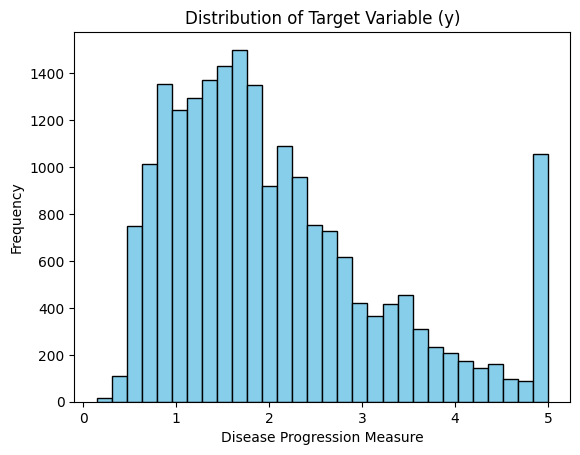

In [28]:
import matplotlib.pyplot as plt 

# Distribution of target variable(y)

plt.hist(y, bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Target Variable (y)")
plt.xlabel("Disease Progression Measure")
plt.ylabel("Frequency")
plt.show()


In [29]:
## Standardizing the X and y
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
y=y.reshape(-1,1)
X_Scaled = scaler.fit_transform(X)
y_Scaled = scaler.fit_transform(y)

### Model implementation 

In [30]:
class MultiLinearReg:

    '''A simple implementation of Multiple Linear regression using Normal Equation(OLS method).
    Provides methods to fit the model, make predictions, and evaluate performance with common metrics like mse,r2_score and adjusted r2_score.'''

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None 

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1) # Adding ones in the first column of the input train matrix 

        # calculating the coefficients 
        betas = np.linalg.pinv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        print("Model fitted")
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict(self,X_test):
        if self.coef_ is None or self.intercept_ is None:
            raise Exception("Model is not fitted yet.")
        X_test = np.insert(X_test,0,1,axis = 1) # Adding ones in the first col of the input test matrix
        betas = np.concatenate(([self.intercept_],self.coef_))
        y_pred = np.dot(X_test,betas)
        return y_pred

    def r2_score(self,X_test,y_test):
        y_pred = self.predict(X_test)
        ss_total = np.sum((y_test - np.mean(y_test))**2)
        ss_res = np.sum((y_test - y_pred)**2)
        return 1-(ss_res/ss_total)
    
    def adjusted_R2(self,X_test,y_test):
        n, k = X_test.shape
        r2 = self.r2_score(X_test,y_test)
        return 1-((1-r2)*(n-1)/(n-k-1))
    
    def mse(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return np.mean((y_test-y_pred)**2)
    
    def mae(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return np.mean(np.abs(y_test-y_pred))
    
    def residuals(self, X_test, y_test):
        y_pred = self.predict(X_test)
        return y_test-y_pred
    

In [31]:
# Training the models 

# My model
my_model = MultiLinearReg()
my_model.fit(X_train, y_train)

# sklearn model 
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)



Model fitted


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Comparision between my model and sklearn model

In [32]:
# Comparision between Intercept and coefficient

print("my_model Intercept: ", my_model.intercept_)
print("sklear Intercept:", sk_model.intercept_)

print("my_model coefficient :",my_model.coef_)
print("sklearn coefficient :",sk_model.coef_)

my_model Intercept:  -36.0228308569675
sklear Intercept: -36.02283090652942
my_model coefficient : [ 4.40945741e-01  9.12556816e-03 -1.13654709e-01  6.19465627e-01
 -6.70834407e-06 -4.09574120e-03 -4.11981515e-01 -4.24539741e-01]
sklearn coefficient : [ 4.40945741e-01  9.12556815e-03 -1.13654709e-01  6.19465627e-01
 -6.70834408e-06 -4.09574120e-03 -4.11981515e-01 -4.24539742e-01]


In [33]:
print("my_model predictions(first 10) :",my_model.predict(X_test[:10]))
print("sklearn predictions(first 10) :",sk_model.predict(X_test[:10]))

my_model predictions(first 10) : [2.80991017 1.25276895 1.44720173 2.48392871 3.42363203 2.66186179
 2.85486934 1.64364753 2.05295858 2.23733339]
sklearn predictions(first 10) : [2.80991017 1.25276895 1.44720173 2.48392871 3.42363203 2.66186179
 2.85486934 1.64364753 2.05295858 2.23733339]


In [34]:
# Comparision between performance metrics 

print("My R²:", my_model.r2_score(X_test, y_test))
print("Sklearn R²:", sk_model.score(X_test, y_test))

print("My MSE:", my_model.mse(X_test, y_test))
print("Sklearn MSE:", mean_squared_error(y_test, sk_model.predict(X_test)))

print("My MAE:", my_model.mae(X_test, y_test))
print("Sklearn MAE:", mean_absolute_error(y_test, sk_model.predict(X_test)))

My R²: 0.6013853271825282
Sklearn R²: 0.6013853272055164
My MSE: 0.5369436868396644
Sklearn MSE: 0.5369436868086989
My MAE: 0.5358292549614447
Sklearn MAE: 0.5358292549658186


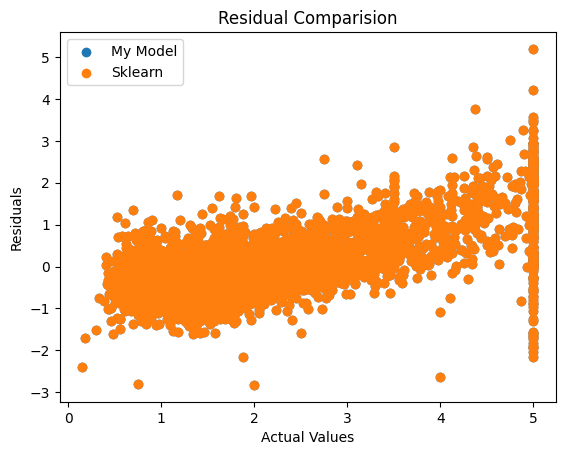

In [35]:
# Residual comparision between my model and sklearn model

plt.scatter(y_test, my_model.residuals(X_test, y_test), label = "My Model")
plt.scatter(y_test, y_test - sk_model.predict(X_test), label="Sklearn")
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Comparision")
plt.legend()

# Conclusion

1. The scratch implementation of **Multiple Linear Regression** produces results that are **identical to sklearn's LinearRegression** in terms of:
   - Coefficients and intercept
   - Predictions
   - Evaluation metrics (R², MSE, MAE)
   - Residual plots

2. This demonstrates:
   - Correctness of the mathematical derivation (Normal Equation)
   - Practical understanding of model fitting and evaluation
   - Ability to implement core machine learning algorithms from scratch

3. Insights:
   - While our implementation works perfectly for small datasets, **sklearn uses numerically stable solvers** (like SVD) that are more robust for large or ill-conditioned datasets.

Overall, this project bridges theory and practice by showing how linear regression works under the hood and how it compares with a standard library implementation.
